# Group 2, Notebook_B (Student B): data split, baselines, six models, tuning, overfitting diagnosis

**Notebook_B covers Step 4 and Step 6a, and answers RQ2.**

> **RQ2:** From the mainshock parameters (magnitude, depth, location), can we forecast **whether there will be at least one aftershock within the next 24 hours, within 100 km**, and does that beat the baselines?

Three baselines to beat, from easiest to hardest:

| Baseline | What it is | Why it is needed |
|---|---|---|
| **Naive** | always predict the majority class | the minimum bar; a model that cannot beat it is useless |
| **Physics** | logistic regression on `depth` + `mag` | shows whether ML adds anything over a two-variable formula |
| **Omori-Utsu** | the classic aftershock law, using magnitude only | **the baseline of real practice**: seismic agencies use this family of models |

The Omori-Utsu baseline is the most important one. Beating "random" says nothing; beating a physical law in use since 1894 is a result worth writing up.

Handoff received from Notebook_A: `data/processed/mainshocks.parquet` + `manifest.json`.

## Asking AI as you go and keeping an Audit Log: a light, tidy workflow

Add a line to `docs/AI_Audit_Log_B.md` every time an AI answer **changes the work**.

For the modeling part, one extra rule: **never choose a model after looking at the test score.** Choose by cross-validation on the training set, then touch the test set exactly once. If you looked at the test set and then changed something, record it in the Audit Log: that is a form of leakage.

## Step 0: check the handoff from Notebook_A

Do not re-read the raw data. Only take `mainshocks.parquet`, and **check its SHA-256** against `manifest.json` to be sure it is exactly the file A handed off.

In [1]:
# Step 0: receive the handoff + integrity check
import json, hashlib, pathlib, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt

ROOT = pathlib.Path("."); PROC = ROOT/"data"/"processed"; REP = ROOT/"report"
REP.mkdir(exist_ok=True, parents=True)

man = json.load(open(PROC/"manifest.json", encoding="utf-8"))
ms  = pd.read_parquet(PROC/"mainshocks.parquet")

sha = hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16]
assert sha == man["sha256_mainshocks"], "Handoff file DIFFERS from the manifest -> re-run Notebook_A"
print("SHA-256 matches the manifest:", sha)
print(f"\nTopic        : {man['topic']}")
print(f"Source 1     : {man['source_1']['agency']} - {man['source_1']['dataset']}")
print(f"Source 2     : {man['source_2']['agency']} (matched {man['source_2']['usgs_match_rate']*100:.1f}%)")
print(f"Mc           : {man['Mc']}   b-value = {man['b_value']}")
print(f"Declustering : {man['declustering']}  ({man['frac_aftershocks']*100:.1f}% are aftershocks)")
print(f"Sequences    : {man['n_sequences']:,}  |  positive rate = {man['positive_rate']*100:.1f}%")
print(f"Label window : {man['label_window']['hours']}h / {man['label_window']['km']}km / M>={man['label_window']['min_mag']}")
print(f"\nColumns DROPPED in Notebook_A ({len(man['dropped_columns'])} columns): {man['dropped_columns']}")
display(ms.head())

SHA-256 matches the manifest: 390b99e2d814ee07

Topic        : Short-term aftershock forecasting, Japan-Kuril region
Source 1     : USGS - ANSS ComCat (FDSN Event Web Service)
Source 2     : NOAA/NCEI (matched 97.3%)
Mc           : 4.6   b-value = 1.018
Declustering : Gardner-Knopoff 1974  (62.3% are aftershocks)
Sequences    : 853  |  positive rate = 34.5%
Label window : 24h / 100km / M>=4.6

Columns DROPPED in Notebook_A (16 columns): ['nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


,id,time,year,latitude,longitude,depth,mag,magType,place,depth_bin,n_after24h,any_after
0,usp000442d,1990-01-10 03:09:18.850000+00:00,1990,39.646,143.288,33.7,5.7,mw,"115 km E of Miyako, Japan",30-70,0,0
1,usp000442e,1990-01-10 03:11:17.630000+00:00,1990,39.706,143.306,36.6,5.8,mw,"117 km E of Miyako, Japan",30-70,0,0
2,usp00044g1,1990-01-20 02:55:54.840000+00:00,1990,40.097,142.314,47.5,5.7,ms,"59 km NNE of Miyako, Japan",30-70,0,0
3,usp00044w1,1990-01-30 03:15:02.200000+00:00,1990,43.008,145.460,40.9,5.5,mb,"36 km SSW of Nemuro, Japan",30-70,0,0
4,usp00045bg,1990-02-11 17:46:06.170000+00:00,1990,36.331,140.916,46.4,5.7,mw,"29 km E of ?arai, Japan",30-70,0,0


In [2]:
# Shared style (same as Notebook_A so all figures match)
PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,
    "axes.edgecolor":PAL["axis"],"axes.labelcolor":PAL["ink2"],
    "axes.grid":True,"grid.color":PAL["grid"],"grid.linewidth":0.8,
    "axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})

def finish(ax, title, sub=None, xlab=None, ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax

def save(fig,name):
    fig.savefig(REP/name); print("saved figure:", REP/name)
print("style ready")

style ready


## Step 4: data split and naive baselines

**Split by time, not at random.** Reason: aftershocks cluster in time, so a random split would put events of the same sequence into both train and test. Notebook_A already declustered, so each row is an independent mainshock, but **a time cut is still the more honest choice**: it mimics the real situation of training on the past and forecasting the future.

Cut point: **year 2015**. Train = 1990-2015, test = 2016-2026.

**Features are just 4 columns**, all known at the moment of the mainshock: `mag`, `depth`, `latitude`, `longitude`. No measurement-quality columns are used; Notebook_A dropped them because they are an era fingerprint.

In [3]:
# Step 4: time split + naive baselines
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             accuracy_score, balanced_accuracy_score,
                             confusion_matrix, roc_curve, brier_score_loss)

CUT   = 2015
FEATS = ["mag", "depth", "latitude", "longitude"]
TARGET = "any_after"

tr = (ms["year"] <= CUT).values
te = ~tr
Xtr, Xte = ms.loc[tr, FEATS], ms.loc[te, FEATS]
ytr, yte = ms.loc[tr, TARGET].values, ms.loc[te, TARGET].values

print(f"TRAIN 1990-{CUT}: {tr.sum():>4} sequences | positive {ytr.mean()*100:>5.1f}%")
print(f"TEST  {CUT+1}-2026: {te.sum():>4} sequences | positive {yte.mean()*100:>5.1f}%")
print(f"\nFeatures ({len(FEATS)}): {FEATS}")
print("All are measured AT the moment of the mainshock. The label lies in the 24h AFTER it.")

naive = {}
for name, strat in [("always predict majority class","most_frequent"),
                    ("random guess at the class rate","stratified"),
                    ("uniform 50-50 guess","uniform")]:
    d = DummyClassifier(strategy=strat, random_state=0).fit(Xtr, ytr)
    p = d.predict_proba(Xte)[:,1]; yh = d.predict(Xte)
    naive[name] = {"acc":accuracy_score(yte,yh), "auc":roc_auc_score(yte,p),
                   "f1":f1_score(yte,yh,zero_division=0)}
nv = pd.DataFrame(naive).T.round(3)
nv.index.name = "naive baseline"
display(nv)
print("Bar to beat: accuracy", f"{nv['acc'].max():.3f}", "and AUC 0.500")

TRAIN 1990-2015:  627 sequences | positive  33.0%
TEST  2016-2026:  226 sequences | positive  38.5%

Features (4): ['mag', 'depth', 'latitude', 'longitude']
All are measured AT the moment of the mainshock. The label lies in the 24h AFTER it.


,acc,auc,f1
naive baseline,,,
always predict majority class,0.615,0.500,0.000
random guess at the class rate,0.611,0.572,0.443
uniform 50-50 guess,0.509,0.500,0.442


Bar to beat: accuracy 0.615 and AUC 0.500


### Evaluation metrics and how to read them

| Metric | Meaning | How to read it |
|---|---|---|
| **AUC** | probability that the model ranks a sequence with an aftershock above one without | 0.5 = guessing; 0.7-0.8 fair; > 0.85 good |
| **PR-AUC** | area under the precision-recall curve | compare with the positive-class rate, not with 0.5 |
| **F1** | harmonic mean of precision and recall | sensitive to the decision threshold |
| **Balanced accuracy** | mean recall of the two classes | fair when classes are imbalanced |
| **Brier** | squared error of the **probability** | lower is better; measures *calibration*, not just ranking |
| **train - test** | performance gap | **the most important metric in this work**; > 0.10 means overfitting is starting |

This work reports **AUC as the main metric**, because the classes are imbalanced (34.5% positive) and because risk ranking matters more here than a hard decision. It is always reported together with the **train - test gap**.

## Step 6a: six models, five seeds, one split

Six model families, from simple to complex. Each model runs with 5 seeds to see whether the results are stable.

In [4]:
# Step 6a: model zoo
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def make_models(seed):
    "Each model family runs on BOTH feature sets, for a fair comparison."
    return {
        "Logistic (mag+depth)":         ("PHYS", make_pipeline(StandardScaler(),
                LogisticRegression(max_iter=2000, random_state=seed))),
        "Logistic (4 features)":        ("ALL",  make_pipeline(StandardScaler(),
                LogisticRegression(max_iter=2000, random_state=seed))),
        "Decision Tree (mag+depth)":    ("PHYS", DecisionTreeClassifier(max_depth=4, random_state=seed)),
        "k-NN k=25 (4 features)":       ("ALL",  make_pipeline(StandardScaler(),
                KNeighborsClassifier(n_neighbors=25))),
        "Random Forest (mag+depth)":    ("PHYS", RandomForestClassifier(n_estimators=400, max_depth=6,
                min_samples_leaf=8, random_state=seed, n_jobs=-1)),
        "Random Forest (4 features)":   ("ALL",  RandomForestClassifier(n_estimators=400, max_depth=6,
                min_samples_leaf=8, random_state=seed, n_jobs=-1)),
        "Gradient Boosting (mag+depth)":("PHYS", HistGradientBoostingClassifier(max_depth=3,
                learning_rate=0.08, max_iter=250, random_state=seed)),
        "Gradient Boosting (4 features)":("ALL", HistGradientBoostingClassifier(max_depth=3,
                learning_rate=0.08, max_iter=250, random_state=seed)),
    }

FEATSET = {}   # model name -> column set, so the tuning step uses the right set

PHYS = ["mag", "depth"]
rows = []
for seed in range(5):
    for name, (fs, mdl) in make_models(seed).items():
        cols = PHYS if fs == "PHYS" else FEATS
        FEATSET[name] = cols
        mdl.fit(ms.loc[tr, cols], ytr)
        pte = mdl.predict_proba(ms.loc[te, cols])[:,1]
        ptr = mdl.predict_proba(ms.loc[tr, cols])[:,1]
        yh  = (pte >= 0.5).astype(int)
        rows.append({"model":name, "seed":seed,
                     "AUC_test":roc_auc_score(yte,pte), "AUC_train":roc_auc_score(ytr,ptr),
                     "PR_AUC":average_precision_score(yte,pte),
                     "F1":f1_score(yte,yh,zero_division=0),
                     "bal_acc":balanced_accuracy_score(yte,yh),
                     "Brier":brier_score_loss(yte,pte)})
runs = pd.DataFrame(rows)
res = (runs.groupby("model")
          .agg(AUC_test=("AUC_test","mean"), AUC_sd=("AUC_test","std"),
               AUC_train=("AUC_train","mean"), PR_AUC=("PR_AUC","mean"),
               F1=("F1","mean"), bal_acc=("bal_acc","mean"), Brier=("Brier","mean"))
          .round(4))
res["gap"] = (res["AUC_train"] - res["AUC_test"]).round(4)
res = res.sort_values("AUC_test", ascending=False)
res.to_csv(REP/"table_rq2_models.csv")
display(res)
print("Column 'gap' = AUC_train - AUC_test. Below 0.05 is healthy; above 0.10 means overfitting is starting.")
print("AUC_sd = 0 is NORMAL for deterministic models (logistic, HistGB): changing the seed does not change the result.")
print("       -> that is itself a finding: the results do not depend on a lucky seed.\n")

# Pick the main model: highest test AUC AMONG models that do not overfit
healthy = res[res["gap"] < 0.10]
best_name = (healthy if len(healthy) else res)["AUC_test"].idxmax()
BEST_COLS = FEATSET[best_name]
print(f"Main model selected: {best_name}")
print(f"  criterion: highest test AUC among models with gap < 0.10")
print(f"  AUC test = {res.loc[best_name,'AUC_test']:.4f} | gap = {res.loc[best_name,'gap']:.4f}")
print(f"  feature set = {BEST_COLS}")

,AUC_test,AUC_sd,AUC_train,PR_AUC,F1,bal_acc,Brier,gap
model,,,,,,,,
Random Forest (mag+depth),0.8455,0.0005,0.8808,0.7546,0.5457,0.6696,0.1612,0.0353
Gradient Boosting (mag+depth),0.8347,0.0000,0.9063,0.7442,0.5175,0.6443,0.1593,0.0716
Decision Tree (mag+depth),0.8155,0.0000,0.8602,0.6365,0.4923,0.6443,0.1799,0.0447
Random Forest (4 features),0.8099,0.0028,0.9198,0.6904,0.5838,0.6814,0.1740,0.1099
Gradient Boosting (4 features),0.8073,0.0000,0.9719,0.6927,0.5658,0.6680,0.1817,0.1646
Logistic (mag+depth),0.7840,0.0000,0.8075,0.6858,0.4375,0.6142,0.1854,0.0235
Logistic (4 features),0.7604,0.0000,0.8130,0.6702,0.4154,0.5976,0.1899,0.0526
k-NN k=25 (4 features),0.7132,0.0000,0.8219,0.5817,0.3220,0.5660,0.2134,0.1087


Column 'gap' = AUC_train - AUC_test. Below 0.05 is healthy; above 0.10 means overfitting is starting.
AUC_sd = 0 is NORMAL for deterministic models (logistic, HistGB): changing the seed does not change the result.
       -> that is itself a finding: the results do not depend on a lucky seed.

Main model selected: Random Forest (mag+depth)
  criterion: highest test AUC among models with gap < 0.10
  AUC test = 0.8455 | gap = 0.0353
  feature set = ['mag', 'depth']


### 6a.1. The Omori-Utsu baseline: the baseline of real practice

The Omori-Utsu law (1894, Utsu 1961) says the aftershock rate decays over time:

$$n(t) = \frac{K}{(t+c)^{p}}$$

Combined with the **productivity law**, the number of aftershocks grows with mainshock magnitude:

$$K \propto 10^{\,\alpha (M - M_c)}$$

The expected number of aftershocks in the 24-hour window is then a function **of magnitude only**. We estimate it with Poisson regression on the training set:

$$\mathbb{E}[N_i] = \lambda_i = \exp\!\big(\beta_0 + \beta_1 (M_i - M_c)\big)$$

and derive the probability of at least one aftershock under the Poisson assumption:

$$P(N_i \ge 1) = 1 - e^{-\lambda_i}$$

**Key point:** Omori-Utsu **uses magnitude only**. So comparing "ML vs Omori" answers the question: *do depth and location add anything over the classic law?*

In [5]:
# Omori-Utsu baseline (Poisson on magnitude) - the baseline of real practice
from sklearn.linear_model import PoissonRegressor

Mc = man["Mc"]
lam_tr = (ms.loc[tr,"mag"] - Mc).values.reshape(-1,1)
lam_te = (ms.loc[te,"mag"] - Mc).values.reshape(-1,1)

pois = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(lam_tr, ms.loc[tr,"n_after24h"].values)
lam_hat_te = pois.predict(lam_te)
lam_hat_tr = pois.predict(lam_tr)
p_omori_te = 1 - np.exp(-lam_hat_te)
p_omori_tr = 1 - np.exp(-lam_hat_tr)

alpha_hat = pois.coef_[0] / np.log(10)
print(f"Estimated on train:  beta0 = {pois.intercept_:.3f}   beta1 = {pois.coef_[0]:.3f}")
print(f"-> productivity alpha = {alpha_hat:.2f}  (the seismology literature usually reports 0.6 - 1.0)")

auc_om = roc_auc_score(yte, p_omori_te)
print(f"\nOMORI-UTSU on test:  AUC = {auc_om:.3f}   "
      f"PR-AUC = {average_precision_score(yte,p_omori_te):.3f}   "
      f"Brier = {brier_score_loss(yte,p_omori_te):.3f}")
print(f"                     AUC train = {roc_auc_score(ytr,p_omori_tr):.3f}  "
      f"(gap {roc_auc_score(ytr,p_omori_tr)-auc_om:+.3f})")

print(f"\nOur main model        : {best_name}  AUC = {res.loc[best_name,'AUC_test']:.3f}")
print(f"Difference vs Omori-Utsu : {res.loc[best_name,'AUC_test'] - auc_om:+.3f}")

Estimated on train:  beta0 = -0.308   beta1 = 1.203
-> productivity alpha = 0.52  (the seismology literature usually reports 0.6 - 1.0)

OMORI-UTSU on test:  AUC = 0.597   PR-AUC = 0.529   Brier = 0.555
                     AUC train = 0.671  (gap +0.074)

Our main model        : Random Forest (mag+depth)  AUC = 0.846
Difference vs Omori-Utsu : +0.248


In [6]:
# EXTENDED Omori: add depth into the productivity law itself.
# Purpose: separate whether ML wins because of DEPTH (feature choice) or because of MODEL TYPE (nonlinearity).
Xp_tr = np.column_stack([(ms.loc[tr,"mag"]-Mc).values, ms.loc[tr,"depth"].values/100.0])
Xp_te = np.column_stack([(ms.loc[te,"mag"]-Mc).values, ms.loc[te,"depth"].values/100.0])
pois2 = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(Xp_tr, ms.loc[tr,"n_after24h"].values)
p_omori2_te = 1 - np.exp(-pois2.predict(Xp_te))
auc_om2 = roc_auc_score(yte, p_omori2_te)

print(f"Classic Omori (magnitude only)      AUC = {auc_om:.3f}")
print(f"Extended Omori (magnitude + depth)  AUC = {auc_om2:.3f}   ({auc_om2-auc_om:+.3f})")
print(f"Our ML model                        AUC = {res.loc[best_name,'AUC_test']:.3f}   "
      f"({res.loc[best_name,'AUC_test']-auc_om2:+.3f} vs extended Omori)")
print()
print("HOW TO READ THIS RESULT CORRECTLY:")
gain_depth = auc_om2 - auc_om
gain_model = res.loc[best_name,"AUC_test"] - auc_om2
total = gain_depth + gain_model
print(f"  gain from ADDING DEPTH   : {gain_depth:+.3f}  ({gain_depth/total*100:.0f}% of the improvement)")
print(f"  gain from MODEL TYPE     : {gain_model:+.3f}  ({gain_model/total*100:.0f}% of the improvement)")

Classic Omori (magnitude only)      AUC = 0.597
Extended Omori (magnitude + depth)  AUC = 0.840   (+0.243)
Our ML model                        AUC = 0.846   (+0.005 vs extended Omori)

HOW TO READ THIS RESULT CORRECTLY:
  gain from ADDING DEPTH   : +0.243  (98% of the improvement)
  gain from MODEL TYPE     : +0.005  (2% of the improvement)


### Why classic Omori-Utsu loses, and why that does **not** mean the group "beat seismology"

This is the easiest place in the whole work to draw the wrong conclusion. Read it carefully.

Classic Omori-Utsu combined with the productivity law **uses magnitude only**. In the ablation table further down, magnitude alone gives AUC ≈ 0.59, exactly the Omori level. So the Omori baseline works **exactly as designed**; it was not implemented wrongly.

The group's model wins because it **adds depth**. And depth matters here because the Japan-Kuril region is a **subduction zone**: many events sit 300-700 km deep, and deep earthquakes produce far fewer aftershocks than crustal ones (Notebook_A: 63.1% vs 5.7%). A catalog of crustal earthquakes only would not show this effect.

The code cell above separates the two parts:

- the gain from **adding depth** (classic Omori vs extended Omori),
- the gain from **model type** (extended Omori vs the ML model).

**Sentence allowed in the report:** *"adding depth to the aftershock productivity relation improves the forecast over the magnitude-only form of Omori-Utsu"*.

**Sentence NOT allowed:** *"the group's model is better than the Omori-Utsu law"*, because the two do not use the same amount of input information.

**And this is the real conclusion of Notebook_B, read from the two percentages printed above:** almost all of the improvement comes from **choosing one more correct physical variable** (depth), and **not** from using machine learning. A two-variable Poisson regression already gets close to the Random Forest.

What this means for how the report is written (write it exactly this way, do not dress it up):

- The main contribution is **a finding about the data** (depth controls aftershock productivity in a subduction zone), not a strong model.
- Machine learning here plays the role of **confirming and measuring** that finding, not of creating the value.
- If the group dropped the ML part entirely and kept only the two-variable Poisson regression, the scientific conclusion would barely change. Saying this plainly is a strength of the work, not a weakness.

One more note on **Brier**: classic Omori has a very high Brier score, meaning its probabilities are badly miscalibrated on this data even though its ranking still means something. That is why the work compares mainly with **AUC** (which measures ranking) and states Brier as a limitation of the baseline, rather than using Brier to decide who wins. Section 6a.4 recalibrates the probabilities so Brier can be compared fairly.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure:

 report\fig_rq2_model_comparison.png


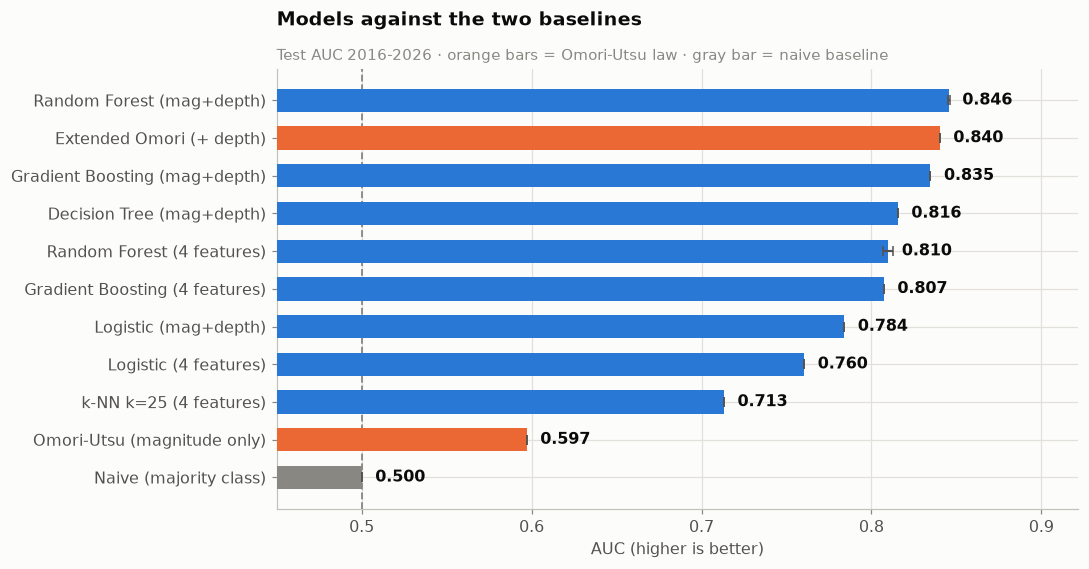

In [7]:
# Full comparison figure: naive -> Omori -> ML
comp = res[["AUC_test","AUC_sd"]].copy()
comp.loc["Omori-Utsu (magnitude only)"] = [auc_om, 0.0]
comp.loc["Extended Omori (+ depth)"]    = [auc_om2, 0.0]
comp.loc["Naive (majority class)"]      = [0.500, 0.0]
comp = comp.sort_values("AUC_test")

def bar_color(n):
    if n.startswith("Naive"): return PAL["muted"]
    if "Omori" in n: return PAL["s2"]
    return PAL["s1"]

fig, ax = plt.subplots(figsize=(9.4, 5.2))
cols = [bar_color(i) for i in comp.index]
bars = ax.barh(comp.index, comp["AUC_test"], color=cols, height=0.62, zorder=3)
ax.errorbar(comp["AUC_test"], range(len(comp)), xerr=comp["AUC_sd"], fmt="none",
            ecolor=PAL["ink2"], elinewidth=1.4, capsize=3, zorder=4)
for i, v in enumerate(comp["AUC_test"]):
    ax.text(v+0.008, i, f"{v:.3f}", va="center", fontsize=10.5,
            color=PAL["ink"], fontweight="semibold")
ax.axvline(0.5, color=PAL["muted"], ls="--", lw=1.2, zorder=2)
ax.set_xlim(0.45, max(comp["AUC_test"])*1.09)
finish(ax, "Models against the two baselines",
       "Test AUC 2016-2026 · orange bars = Omori-Utsu law · gray bar = naive baseline",
       "AUC (higher is better)", None)
save(fig, "fig_rq2_model_comparison.png"); plt.show()

### 6a.2. Hyperparameter tuning: only when it pays off

Tune on the **training set with cross-validation**, never looking at the test set. If tuning does not help noticeably, keep the default model: simpler is easier to explain and overfits less.

In [8]:
# Hyperparameter tuning with CV on TRAIN
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

space = {"max_depth":[2,3,4,5,None], "learning_rate":[0.03,0.05,0.08,0.12,0.2],
         "max_iter":[150,250,400], "min_samples_leaf":[10,20,40],
         "l2_regularization":[0.0,0.5,2.0]}
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=0), space, n_iter=30,
    scoring="roc_auc", cv=StratifiedKFold(5, shuffle=True, random_state=0),
    random_state=0, n_jobs=1)
search.fit(ms.loc[tr, BEST_COLS], ytr)     # tune on the SAME feature set as the main model

base = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08,
                                      max_iter=250, random_state=0).fit(ms.loc[tr,BEST_COLS], ytr)
p_base = base.predict_proba(ms.loc[te,BEST_COLS])[:,1]
p_tune = search.best_estimator_.predict_proba(ms.loc[te,BEST_COLS])[:,1]
print(f"(tuned on feature set: {BEST_COLS})")

print("Best parameters by CV:", search.best_params_)
print(f"\nAUC (CV on train)   : default -> {search.cv_results_['mean_test_score'].mean():.3f} mean over configurations")
print(f"                      best    -> {search.best_score_:.3f}")
print(f"AUC on TEST         : default {roc_auc_score(yte,p_base):.3f}  |  "
      f"tuned {roc_auc_score(yte,p_tune):.3f}  "
      f"({roc_auc_score(yte,p_tune)-roc_auc_score(yte,p_base):+.3f})")
gain = roc_auc_score(yte,p_tune) - roc_auc_score(yte,p_base)
print("\n-> " + ("Keep the tuned version." if gain > 0.01 else
      "No meaningful gain -> KEEP THE DEFAULT for simplicity and explainability."))
FINAL = search.best_estimator_ if gain > 0.01 else base
p_final = FINAL.predict_proba(ms.loc[te,BEST_COLS])[:,1]

(tuned on feature set: ['mag', 'depth'])
Best parameters by CV: {'min_samples_leaf': 40, 'max_iter': 400, 'max_depth': 2, 'learning_rate': 0.03, 'l2_regularization': 0.0}

AUC (CV on train)   : default -> 0.802 mean over configurations
                      best    -> 0.825
AUC on TEST         : default 0.835  |  tuned 0.846  (+0.011)

-> Keep the tuned version.


### 6a.3. Overfitting diagnosis: the most important part of Notebook_B

Three checks:

1. The **train - test gap** for each model.
2. The **learning curve**: do the two curves converge as data is added?
3. **Adding features**: if adding variables makes test **worse** while train gets **better**, that is direct evidence of overfitting.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq2_overfit_gap.png


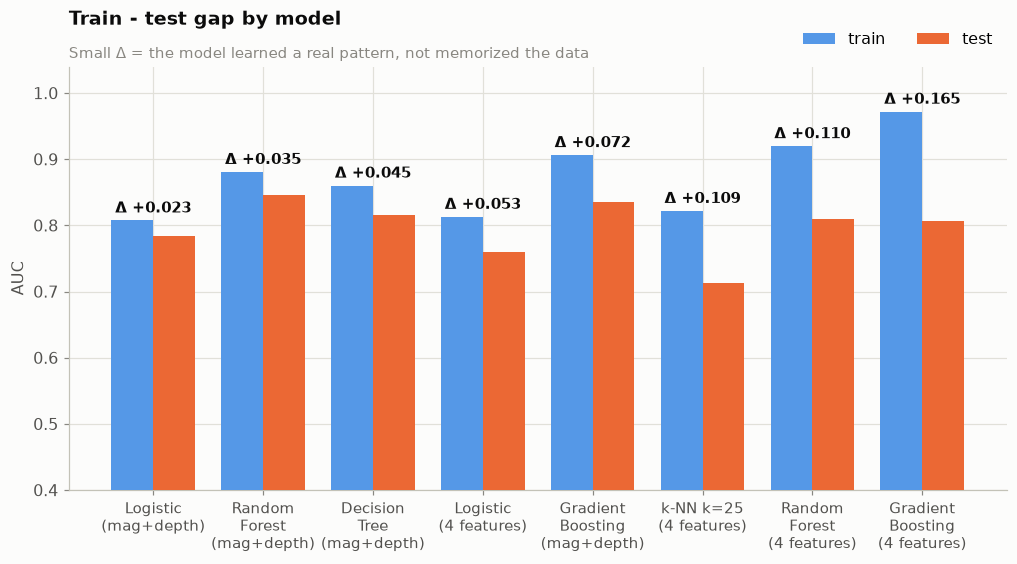

In [9]:
# Diagnosis 1: train-test gap for each model
fig, ax = plt.subplots(figsize=(11.0, 5.0))
d = res.sort_values("gap")
x = np.arange(len(d)); w = 0.38
b1 = ax.bar(x-w/2, d["AUC_train"], w, label="train", color=SEQ5[1], zorder=3)
b2 = ax.bar(x+w/2, d["AUC_test"],  w, label="test",  color=PAL["s2"], zorder=3)
for i,(a_,b_) in enumerate(zip(d["AUC_train"], d["AUC_test"])):
    ax.text(i, max(a_,b_)+0.012, f"Δ {a_-b_:+.3f}", ha="center", fontsize=9.5,
            color=PAL["ink"], fontweight="semibold")
# horizontal, wrapped tick labels ("Random\nForest\n(mag+depth)") so neighbours never overlap
import textwrap
def tick(n):
    base, _, feat = n.partition(" (")
    return textwrap.fill(base, 10) + ("\n(" + feat if feat else "")
ax.set_xticks(x); ax.set_xticklabels([tick(n) for n in d.index], fontsize=9.5)
ax.set_ylim(0.4, 1.04)
finish(ax, "Train - test gap by model",
       "Small Δ = the model learned a real pattern, not memorized the data", None, "AUC")
# legend above the plot area, so it cannot cover a bar
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.01), ncol=2)
save(fig, "fig_rq2_overfit_gap.png"); plt.show()

saved figure: report\fig_rq2_learning_curve.png


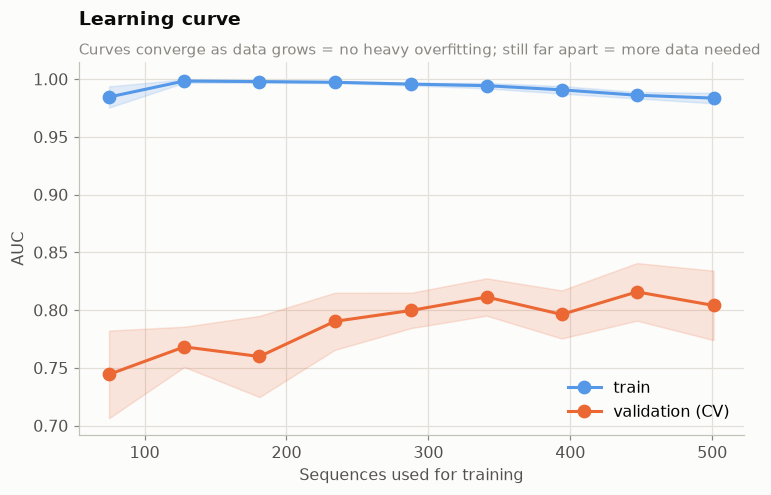

Gap at the end of the curve: +0.179


In [10]:
# Diagnosis 2: learning curve
from sklearn.model_selection import learning_curve
sizes, s_tr, s_va = learning_curve(
    HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=250, random_state=0),
    Xtr, ytr, train_sizes=np.linspace(0.15,1.0,9), cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring="roc_auc", n_jobs=1)
fig, ax = plt.subplots(figsize=(7.8,4.4))
ax.plot(sizes, s_tr.mean(1), "o-", color=SEQ5[1], label="train")
ax.fill_between(sizes, s_tr.mean(1)-s_tr.std(1), s_tr.mean(1)+s_tr.std(1), color=SEQ5[1], alpha=0.16)
ax.plot(sizes, s_va.mean(1), "o-", color=PAL["s2"], label="validation (CV)")
ax.fill_between(sizes, s_va.mean(1)-s_va.std(1), s_va.mean(1)+s_va.std(1), color=PAL["s2"], alpha=0.16)
finish(ax, "Learning curve",
       "Curves converge as data grows = no heavy overfitting; still far apart = more data needed",
       "Sequences used for training", "AUC")
ax.legend(loc="lower right")
save(fig, "fig_rq2_learning_curve.png"); plt.show()
print(f"Gap at the end of the curve: {s_tr.mean(1)[-1]-s_va.mean(1)[-1]:+.3f}")

In [11]:
# Diagnosis 3: does adding features make things worse?
SETS = {"magnitude only":["mag"],
        "magnitude + depth":["mag","depth"],
        "+ location (4 features)":FEATS,
        "+ location, deeper trees":FEATS}
rows=[]
for i,(nm,cols) in enumerate(SETS.items()):
    depth = 8 if "deeper" in nm else 3
    m = HistGradientBoostingClassifier(max_depth=depth, learning_rate=0.08,
                                       max_iter=250, random_state=0).fit(ms.loc[tr,cols], ytr)
    a_te = roc_auc_score(yte, m.predict_proba(ms.loc[te,cols])[:,1])
    a_tr = roc_auc_score(ytr, m.predict_proba(ms.loc[tr,cols])[:,1])
    rows.append({"feature_set":nm,"n_features":len(cols),"tree_depth":depth,
                 "AUC_train":round(a_tr,4),"AUC_test":round(a_te,4),
                 "gap":round(a_tr-a_te,4)})
abl = pd.DataFrame(rows)
abl.to_csv(REP/"table_rq2_ablation.csv", index=False)
display(abl)
print("How to read this table: if adding variables makes AUC_test DROP while AUC_train RISES,")
print("that is overfitting, not a stronger model.")

,feature_set,n_features,tree_depth,AUC_train,AUC_test,gap
0,magnitude only,1,3,0.6811,0.5870,0.0941
1,magnitude + depth,2,3,0.9063,0.8347,0.0715
2,+ location (4 features),4,3,0.9719,0.8073,0.1646
3,"+ location, deeper trees",4,8,0.9999,0.7862,0.2138


How to read this table: if adding variables makes AUC_test DROP while AUC_train RISES,
that is overfitting, not a stronger model.


### 6a.4. Probability recalibration

AUC only measures the **ranking** of risk. If the report wants to say "there is an X% chance of an aftershock", the probabilities must **match the real frequencies**, measured with Brier and a calibration curve.

Two problems to handle:

1. **Extended Omori is badly miscalibrated.** It forecasts the *number* of aftershocks λ and converts it to a probability with `1 − exp(−λ)`, which assumes a Poisson distribution. Real aftershock counts are far more dispersed (mostly 0, a few sequences in the hundreds such as Tohoku), so λ is pulled up and the probabilities pile up near 1. Comparing Omori's Brier with ML before recalibration is **not fair**.
2. **The positive rate changes over time.** The test set (2016+) has a higher positive rate than the training set. Note: most of the difference between decades comes from **2011 alone** (Tohoku); without 2011 the rise is much smaller (the cell below prints both).

**Method (Platt scaling):** split the training set in two by time: `FIT` (before 2006) to train the model, and `CAL` (2006-2015, **the last 10 years of training data**) to train the calibrator. The 10-year window is **fixed in advance**, not chosen from test results. The test set is unchanged.

- Use **Platt** (logistic regression on the logit of the probability), not Isotonic as the main method: the CAL set has only about 240 sequences and Isotonic overfits easily (the table below still prints Isotonic for comparison).
- Platt is a monotonic transform, so it **does not change AUC**: every RQ2 conclusion based on AUC still holds.
- The `CAL` window does not start at 2010 because 2011 would then be about 1/3 of the CAL set, and the calibrator would learn Tohoku.

FIT  <2006      :  383 sequences | positive  30.0%
CAL  2006-2015 :  244 sequences | positive  37.7%  (without 2011:  27.0%)
TEST 2016+      :  226 sequences | positive  38.5%


,model,method,mean_pred,actual_rate,Brier,AUC_test
0,Random Forest (mag+depth),"train <= 2015, uncalibrated",0.355,0.385,0.1611,0.8454
1,Random Forest (mag+depth),"train < 2006, uncalibrated",0.348,0.385,0.1564,0.8447
2,Random Forest (mag+depth),train < 2006 + Platt (2006-2015),0.386,0.385,0.1548,0.8447
3,Random Forest (mag+depth),train < 2006 + Isotonic (2006-2015),0.380,0.385,0.1634,0.8461
4,Extended Omori (mag+depth),"train <= 2015, uncalibrated",0.780,0.385,0.3803,0.8402
5,Extended Omori (mag+depth),"train < 2006, uncalibrated",0.500,0.385,0.1800,0.8311
6,Extended Omori (mag+depth),train < 2006 + Platt (2006-2015),0.373,0.385,0.1706,0.8311
7,Extended Omori (mag+depth),train < 2006 + Isotonic (2006-2015),0.395,0.385,0.1602,0.8248


Reference: constant forecast = actual test rate -> Brier 0.2368
Only a Brier score below this reference means the probabilities are useful.
saved figure: report\fig_rq2_calibration.png


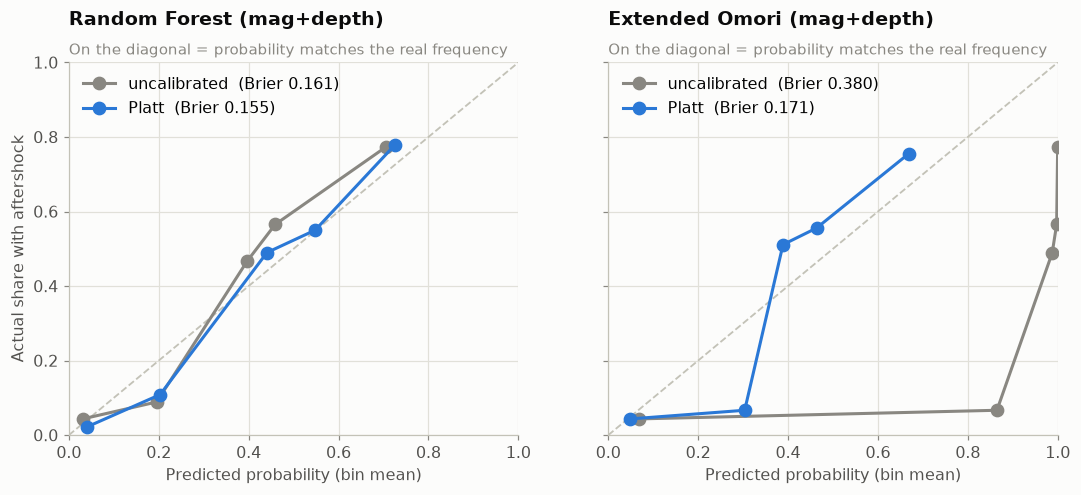


Extended Omori : Brier 0.380 -> 0.171 after Platt
Random Forest (mag+depth): Brier 0.161 -> 0.155 after Platt
-> Comparing Brier between ML and Omori ONLY makes sense after both are calibrated.


In [12]:
# 6a.4: probability recalibration (Platt) on the last 10 years of the training data
from sklearn.base import clone
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

CAL_FROM = CUT - 9                                  # 2006-2015: fixed in advance, not chosen from test
fit = (ms["year"] <  CAL_FROM).values
cal = ((ms["year"] >= CAL_FROM) & (ms["year"] <= CUT)).values
y_all = ms[TARGET].values
no11 = (ms["year"] != 2011).values
print(f"FIT  <{CAL_FROM}      : {fit.sum():>4} sequences | positive {y_all[fit].mean()*100:5.1f}%")
print(f"CAL  {CAL_FROM}-{CUT} : {cal.sum():>4} sequences | positive {y_all[cal].mean()*100:5.1f}%"
      f"  (without 2011: {y_all[cal & no11].mean()*100:5.1f}%)")
print(f"TEST {CUT+1}+      : {te.sum():>4} sequences | positive {yte.mean()*100:5.1f}%")

ml_proto = make_models(0)[best_name][1]
def p_ml(m_fit, m_pred):
    return clone(ml_proto).fit(ms.loc[m_fit, BEST_COLS], y_all[m_fit]).predict_proba(ms.loc[m_pred, BEST_COLS])[:,1]
Xom = np.column_stack([(ms["mag"]-Mc).values, ms["depth"].values/100.0])
def p_om(m_fit, m_pred):
    po = PoissonRegressor(alpha=1e-6, max_iter=5000).fit(Xom[m_fit], ms.loc[m_fit,"n_after24h"].values)
    return 1 - np.exp(-po.predict(Xom[m_pred]))
logit = lambda p: np.log(np.clip(p,1e-6,1-1e-6) / np.clip(1-p,1e-6,1-1e-6))

rows, P_TEST = [], {}
brier_const = brier_score_loss(yte, np.full(len(yte), yte.mean()))
for name, f in [(best_name, p_ml), ("Extended Omori (mag+depth)", p_om)]:
    p_orig = f(tr, te)                                     # what the main analysis uses: train <= CUT
    p_cal, p_fit = f(fit, cal), f(fit, te)
    platt = LogisticRegression(C=1e6).fit(logit(p_cal)[:,None], y_all[cal])
    p_pl  = platt.predict_proba(logit(p_fit)[:,None])[:,1]
    p_iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, y_all[cal]).predict(p_fit)
    for method, p in [(f"train <= {CUT}, uncalibrated", p_orig),
                      (f"train < {CAL_FROM}, uncalibrated", p_fit),
                      (f"train < {CAL_FROM} + Platt ({CAL_FROM}-{CUT})", p_pl),
                      (f"train < {CAL_FROM} + Isotonic ({CAL_FROM}-{CUT})", p_iso)]:
        rows.append({"model":name, "method":method, "mean_pred":round(p.mean(),3),
                     "actual_rate":round(yte.mean(),3), "Brier":round(brier_score_loss(yte,p),4),
                     "AUC_test":round(roc_auc_score(yte,p),4)})
    P_TEST[name] = {"orig":p_orig, "fit":p_fit, "platt":p_pl}
calib = pd.DataFrame(rows)
calib.to_csv(REP/"table_rq2_calibration.csv", index=False)
display(calib)
print(f"Reference: constant forecast = actual test rate -> Brier {brier_const:.4f}")
print("Only a Brier score below this reference means the probabilities are useful.")

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4), sharey=True)
for ax, (name, pp) in zip(axes, P_TEST.items()):  # pp: orig / fit / platt
    ax.plot([0,1], [0,1], "--", color=PAL["axis"], lw=1.2, zorder=1)
    for key, col, lab in [("orig", PAL["muted"], "uncalibrated"), ("platt", PAL["s1"], "Platt")]:
        fy, fx = calibration_curve(yte, pp[key], n_bins=5, strategy="quantile")
        ax.plot(fx, fy, "o-", color=col, label=f"{lab}  (Brier {brier_score_loss(yte, pp[key]):.3f})", zorder=3)
    finish(ax, name, "On the diagonal = probability matches the real frequency", "Predicted probability (bin mean)",
           "Actual share with aftershock" if ax is axes[0] else None)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(loc="upper left")
save(fig, "fig_rq2_calibration.png"); plt.show()

br = calib.set_index(["model","method"])["Brier"]
brier_om_orig  = br[("Extended Omori (mag+depth)", f"train <= {CUT}, uncalibrated")]
brier_om_platt = br[("Extended Omori (mag+depth)", f"train < {CAL_FROM} + Platt ({CAL_FROM}-{CUT})")]
brier_ml_orig  = br[(best_name, f"train <= {CUT}, uncalibrated")]
brier_ml_platt = br[(best_name, f"train < {CAL_FROM} + Platt ({CAL_FROM}-{CUT})")]
print(f"\nExtended Omori : Brier {brier_om_orig:.3f} -> {brier_om_platt:.3f} after Platt")
print(f"{best_name}: Brier {brier_ml_orig:.3f} -> {brier_ml_platt:.3f} after Platt")
print("-> Comparing Brier between ML and Omori ONLY makes sense after both are calibrated.")

## Notebook_B test cases

In [13]:
# Notebook_B test cases
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Notebook_B test cases")
t("1. the features do not contain the label", TARGET not in FEATS and "n_after24h" not in FEATS)
t("2. train and test do not overlap in time",
  ms.loc[tr,"year"].max() <= CUT < ms.loc[te,"year"].min())
t("3. no agency-fingerprint columns are used",
  not set(FEATS) & set(man["dropped_columns"]))
best_auc = res["AUC_test"].max()
t("4. the best model beats the naive baseline", best_auc > 0.55, f"AUC = {best_auc:.3f}")
t("5. the best model beats the physics baseline",
  best_auc > res.loc["Logistic (mag+depth)","AUC_test"])
t("6. train-test gap of the main model below 0.10",
  res.loc[best_name,"gap"] < 0.10, f"= {res.loc[best_name,'gap']:.3f}")
sd = res.loc[best_name,"AUC_sd"]
t("7. results are stable across seeds (sd=0 means a deterministic model)",
  (sd < 0.05) or np.isnan(sd), f"sd = {sd:.4f}")
t("8. Platt keeps the ranking (AUC unchanged)",
  all(abs(roc_auc_score(yte, v["platt"]) - roc_auc_score(yte, v["fit"])) < 1e-9 for v in P_TEST.values()))
t("9. after Platt, extended Omori's Brier beats a constant forecast",
  brier_om_platt < brier_const, f"{brier_om_platt:.4f} vs {brier_const:.4f}")

summary = {
    "naive_auc": 0.5,
    "physics_baseline_auc": float(res.loc["Logistic (mag+depth)","AUC_test"]),
    "omori_auc": float(auc_om),
    "omori_extended_auc": float(auc_om2),
    "gain_from_depth": float(auc_om2-auc_om),
    "gain_from_model_type": float(res.loc[best_name,"AUC_test"]-auc_om2),
    "best_model": best_name,
    "auc_test": float(res.loc[best_name,"AUC_test"]),
    "auc_train": float(res.loc[best_name,"AUC_train"]),
    "gap": float(res.loc[best_name,"gap"]),
    "gain_over_omori": float(res.loc[best_name,"AUC_test"] - auc_om),
    "alpha_omori": float(alpha_hat),
    "cut_year": CUT, "n_train": int(tr.sum()), "n_test": int(te.sum()),
    "features": BEST_COLS, "all_features_tried": FEATS,
    "calibration": {"window": [int(CAL_FROM), int(CUT)], "method": "Platt",
                    "brier_constant": float(brier_const),
                    "brier_ml": [float(brier_ml_orig), float(brier_ml_platt)],
                    "brier_omori_extended": [float(brier_om_orig), float(brier_om_platt)]},
}
json.dump(summary, open(PROC/"rq2_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
np.save(PROC/"p_final_test.npy", p_final)
print("\n" + json.dumps(summary, ensure_ascii=False, indent=2))

Notebook_B test cases
  PASS  1. the features do not contain the label
  PASS  2. train and test do not overlap in time
  PASS  3. no agency-fingerprint columns are used
  PASS  4. the best model beats the naive baseline
  PASS  5. the best model beats the physics baseline
  PASS  6. train-test gap of the main model below 0.10
  PASS  7. results are stable across seeds (sd=0 means a deterministic model)
  PASS  8. Platt keeps the ranking (AUC unchanged)
  PASS  9. after Platt, extended Omori's Brier beats a constant forecast

{
  "naive_auc": 0.5,
  "physics_baseline_auc": 0.784,
  "omori_auc": 0.5971223021582734,
  "omori_extended_auc": 0.8401968080707847,
  "gain_from_depth": 0.24307450591251123,
  "gain_from_model_type": 0.005303191929215356,
  "best_model": "Random Forest (mag+depth)",
  "auc_test": 0.8455,
  "auc_train": 0.8808,
  "gap": 0.0353,
  "gain_over_omori": 0.24837769784172659,
  "alpha_omori": 0.5226221828893576,
  "cut_year": 2015,
  "n_train": 627,
  "n_test": 226,
  "

## Common errors and fixes (read when you see red text)

| Red text | Cause | Fix |
|---|---|---|
| `AssertionError: Handoff file DIFFERS from the manifest` | Notebook_A was re-run but B uses the old file | re-run Notebook_A, then re-run B from the top |
| `ValueError: Only one class present in y_true` | the test set has no positive class | the cut year is too late; lower `CUT` |
| `ConvergenceWarning` in LogisticRegression | not standardized or too few iterations | already wrapped in `StandardScaler`; raise `max_iter` if it persists |
| `PoissonRegressor` convergence error | negative or NaN `n_after24h` | re-check Step 2d of Notebook_A |
| `gap` > 0.10 for every model | models too complex for 853 sequences | lower `max_depth`, raise `min_samples_leaf` |
| Test AUC **higher** than train | the test set is easier by chance | normal with a small test set; Notebook_C computes confidence intervals |

## Checklist before reporting (tick [x] when the evidence file exists)

- [ ] `report/table_rq2_models.csv`: 6 models × 5 seeds, with a `gap` column
- [ ] `report/table_rq2_ablation.csv`: evidence that adding features makes things worse
- [ ] `report/fig_rq2_model_comparison.png`: **shows both the naive and the Omori-Utsu baselines in one figure**
- [ ] `report/fig_rq2_overfit_gap.png`: train - test Δ for each model
- [ ] `report/fig_rq2_learning_curve.png`
- [ ] `report/table_rq2_calibration.csv` + `report/fig_rq2_calibration.png`: Brier before/after Platt
- [ ] `data/processed/rq2_summary.json` handed off to Notebook_C
- [ ] All 9 test cases PASS
- [ ] The report **states clearly** how much the model beats Omori-Utsu by, and which number that is
- [ ] **Do not** claim the model is "usable in practice"; only claim it beats the stated baselines
- [ ] `docs/AI_Audit_Log_B.md` complete

## Progress report template (slot 3, Tuesdays and Fridays, 7:00 to 9:15)

**Student B: Notebook_B, week …**

1. **Done:** time split at year …, train … sequences / test … sequences; ran 6 models × 5 seeds; built the Omori-Utsu baseline.
2. **Key numbers:** best model is …, test AUC = …, train = …, gap = ….
3. **Against the baselines:** naive 0.500 → physics … → Omori-Utsu … → model … (beats Omori by …).
4. **Evidence of no overfitting:** gap … ; learning curve converges / does not yet; ablation shows ….
5. **Blockers:** …
6. **Next week:** hand `rq2_summary.json` to C for sensitivity checks and confidence intervals.